# Cloud satellite estimation (clean)

Reproduces the analysis in `cloud_satellite.ipynb` using the `goesclouds`
module. Every cell is one or two calls into `goesclouds`; intermediate
DataFrames live as notebook variables so they can be inspected directly.
See `goesclouds.md` for the full design and `goesclouds.py` for the
implementation.

In [1]:
%load_ext autoreload
%autoreload 1
%aimport goesclouds
import goesclouds as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gc.configure_notebook_logging()

## Load and sample

In [2]:
quarter_reports  = gc.load_quarter_reports()
sample_quarters  = gc.select_sample_quarters(quarter_reports)
missing_quarters = gc.select_missing_quarters(quarter_reports, year=2015)
len(quarter_reports), len(sample_quarters), len(missing_quarters)

(69652, 891, 180)

## Single-band analysis

Pixel samples for one band, summary stats, and the per-quarter
brightness-based cloud-eighths estimate.

2026-09-11 17:19:18,444 - WARNING - could not read /media/psf/aisandbox/goesclouds/data/satellite_2013-04-27_q3/GOES13_4_2013-04-28T051603.nc
2026-09-11 17:19:19,013 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-02_q2/GOES13_4_2013-09-10T233725.nc: timestamp 2013-09-10 23:37:25 is more than 2 day(s) outside the quarter window [2013-09-03 02:05:55, 2013-09-03 04:42:08]
2026-09-11 17:19:19,017 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-04_q2/GOES13_4_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 02:06:06, 2013-09-05 04:41:29]
2026-09-11 17:19:19,018 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-04_q3/GOES13_4_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 04:41:29, 2013-09-05 07:16:52]
2026-09-11 17:19:19,019 - WARNING - skipping /media/psf/aisandbox/goesclouds/data

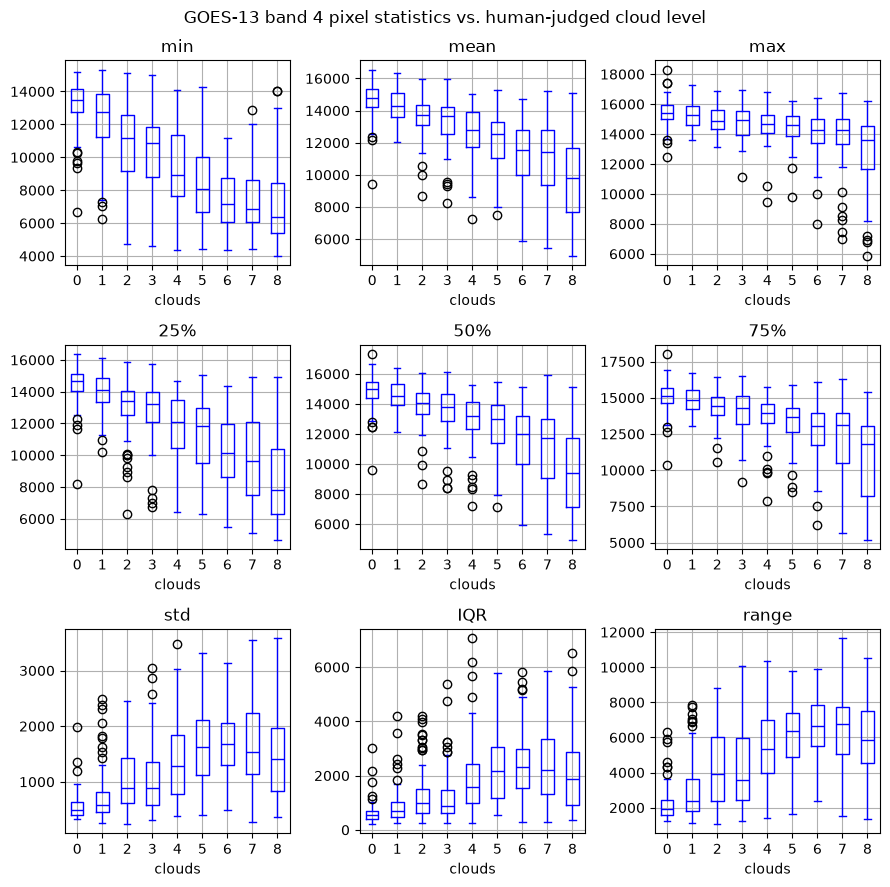

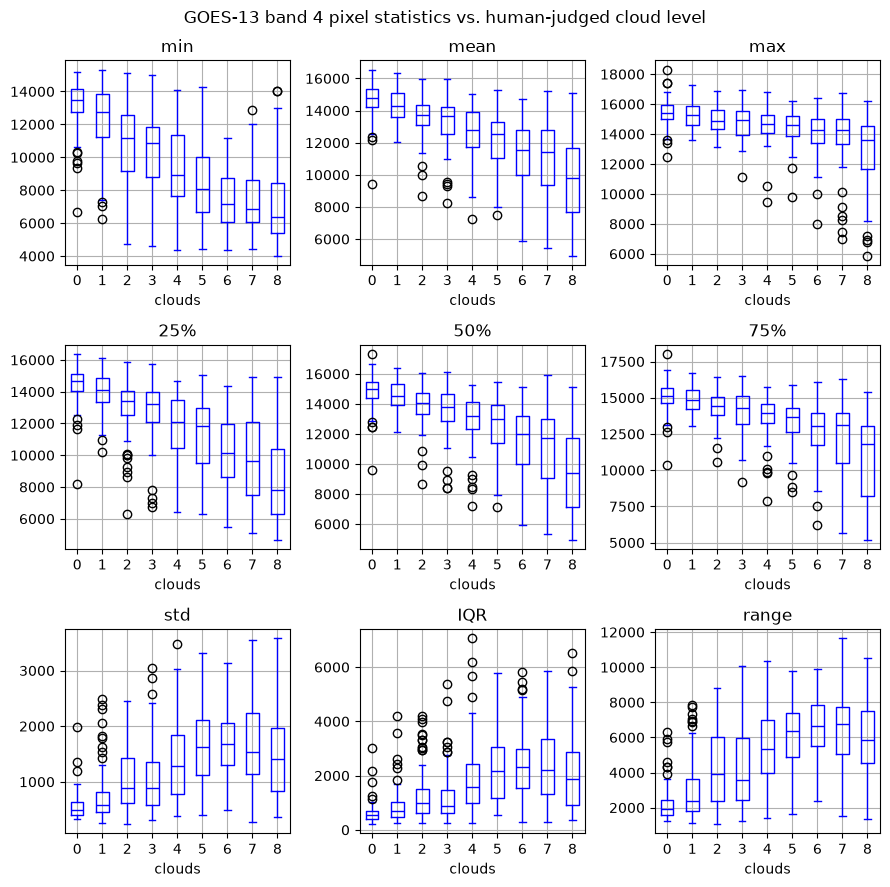

In [3]:
band = 4
band_samples = gc.extract_band_samples(sample_quarters, band=band)
stats        = gc.compute_sample_stats(band_samples)
gc.plot_sample_stats(stats, band=band)

13664

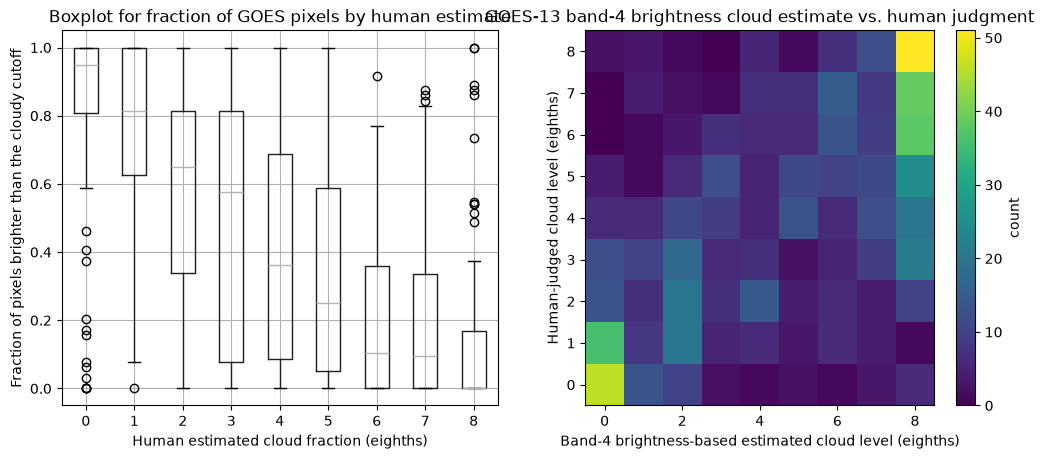

In [4]:
#cloudcut   = gc.reference_quantile(band_samples, f"band{band}")
cloudcut   = gc.optimize_cloudcut_obs(band_samples, f"band{band}")
by_quarter = gc.compute_by_quarter(band_samples, f"band{band}", cloudcut)
gc.plot_by_quarter(by_quarter, band=band)
cloudcut

## Fill missing quarters, one band

`cloudcut` comes from the calibration sample and is reused, unchanged, for
the 2015 quarters with a missing human report.

PosixPath('satellite_clouds_band4_2015.txt')

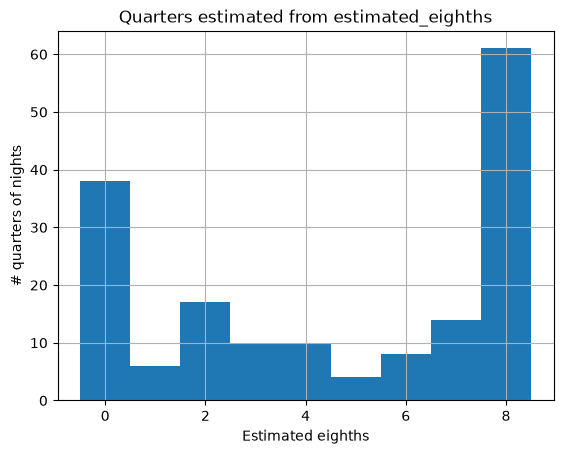

In [5]:
missing_samples    = gc.extract_band_samples(missing_quarters, band=band)
missing_by_quarter = gc.compute_by_quarter(missing_samples, f"band{band}", cloudcut)
gc.plot_estimate_histogram(missing_by_quarter)
gc.write_band_estimates(missing_by_quarter, f"satellite_clouds_band{band}_2015.txt")

## Multi-band comparison

Join bands 2, 4, and 6 into one pixel-indexed frame, then build the
`(band, stat)`-columned `sample_stats` frame as per-band
`compute_sample_stats` + `pd.concat` (there is no
`compute_sample_stats_multiband` -- see `goesclouds.md` §7.4).

In [6]:
multiband = gc.load_multiband_samples(sample_quarters, bands=(2, 4, 6))

human_clouds = None
band_stat_frames = {}
for b in (2, 4, 6):
    band_values = gc.as_value_frame(multiband, (b, "value"))
    s = gc.compute_sample_stats(band_values, value_column="value")
    human_clouds = s["clouds"]
    del s["clouds"]
    s.columns = pd.MultiIndex.from_product([[b], s.columns])
    band_stat_frames[b] = s
multiband_stats = pd.concat(band_stat_frames.values(), axis=1)
multiband_stats[("human", "clouds")] = human_clouds

2026-09-11 17:19:37,224 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-02_q2/GOES13_2_2013-09-10T233725.nc: timestamp 2013-09-10 23:37:25 is more than 2 day(s) outside the quarter window [2013-09-03 02:05:55, 2013-09-03 04:42:08]
2026-09-11 17:19:37,225 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-04_q2/GOES13_2_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 02:06:06, 2013-09-05 04:41:29]
2026-09-11 17:19:37,226 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-04_q3/GOES13_2_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 04:41:29, 2013-09-05 07:16:52]
2026-09-11 17:19:37,230 - WARNING - skipping /media/psf/aisandbox/goesclouds/data/satellite_2013-09-07_q3/GOES13_2_2013-09-11T022532.nc: timestamp 2013-09-11 02:25:32 is more than 2 day(s) outside the quarter window [2013-0

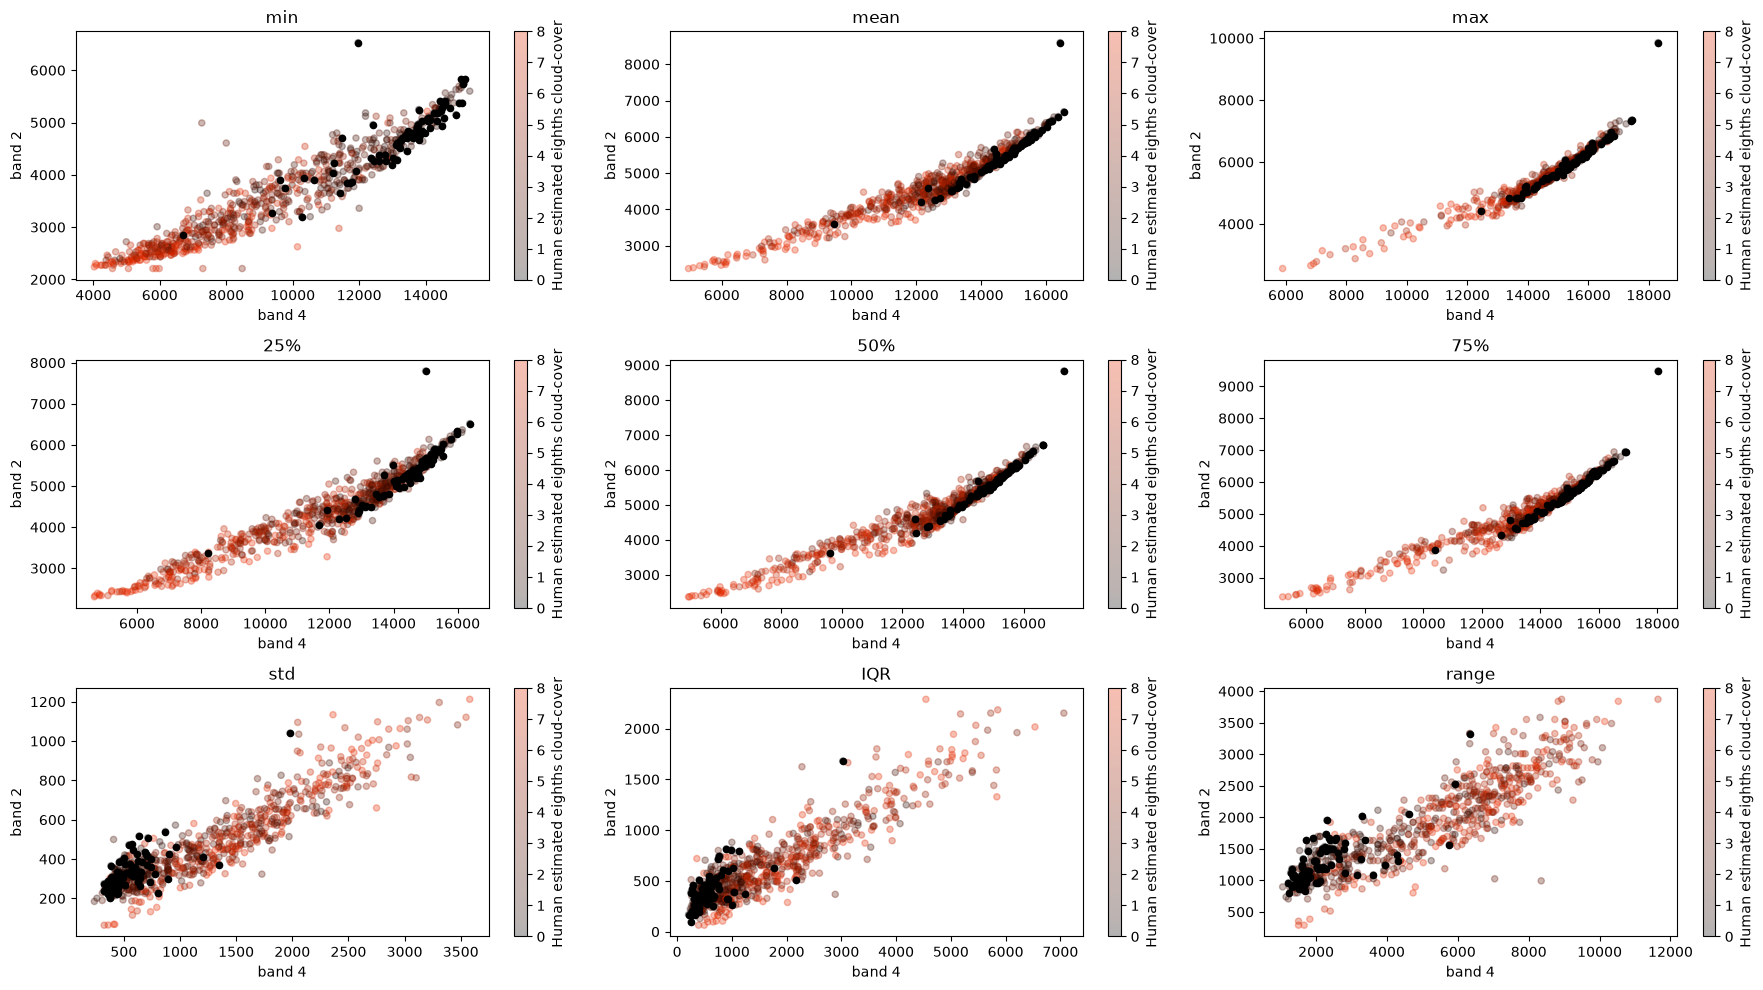

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
clear = multiband_stats[("human", "clouds")] == 0
for stat_name, ax in zip(gc.STAT_NAMES, axes.flatten()):
    gc.plot_band_comparison(multiband_stats, stat_name, ax, 4, 2, clear_mask=clear)
fig.tight_layout()

## Band-2-corrected estimator

Fit a per-pixel clear-sky relation of band 4 against band 2, and use it
to correct band-4 brightness for each pixel's own clear-sky baseline.

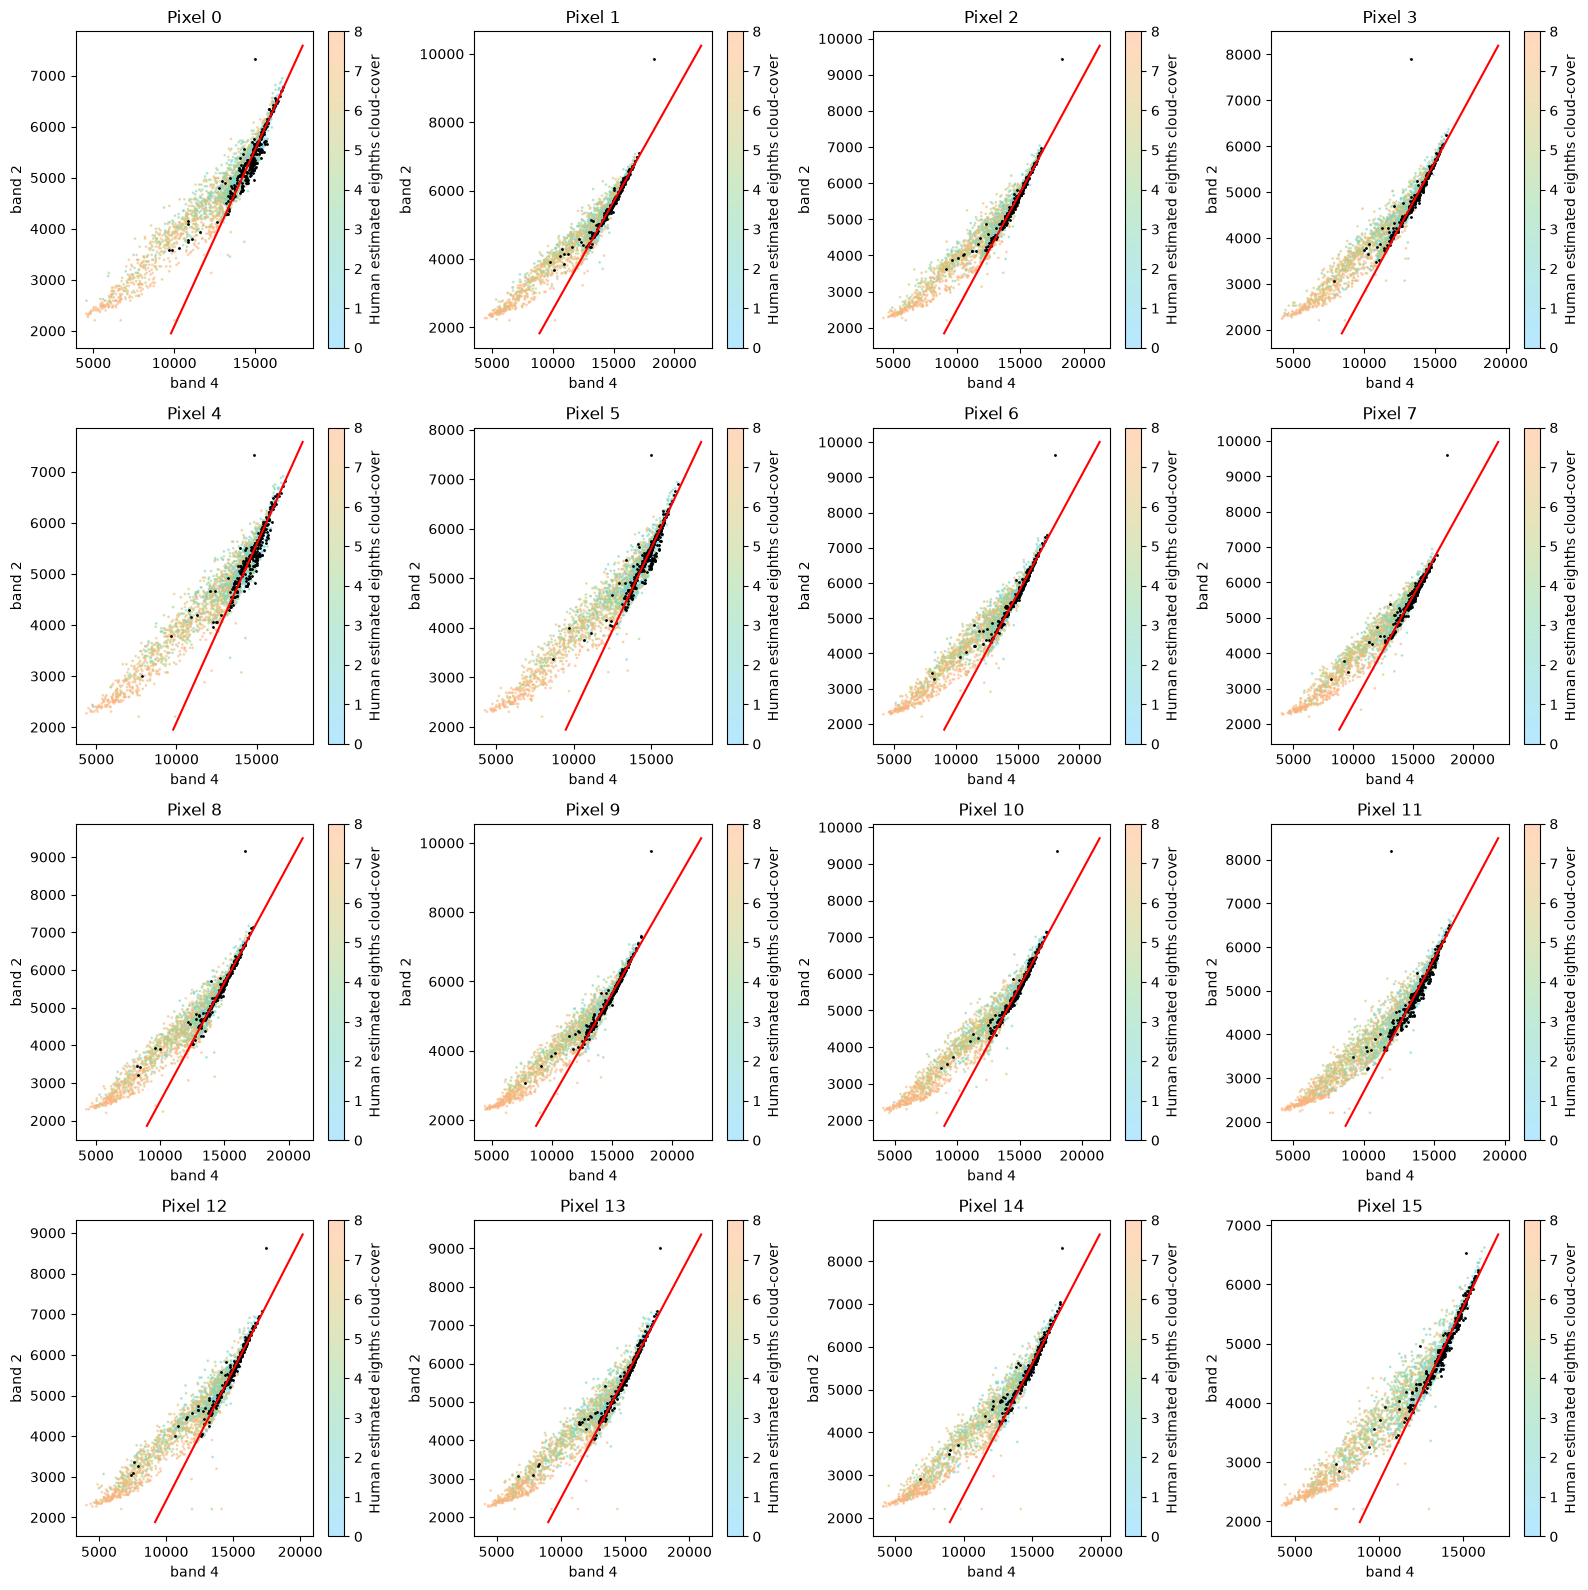

In [8]:
models    = gc.fit_clear_sky_model(multiband, x_band=2, y_band=4, per_pixel=True)
corrected = gc.apply_clear_sky_correction(multiband, models, x_band=2, y_band=4)
gc.plot_per_pixel_models(corrected, models, x_band=4, y_band=2)
None

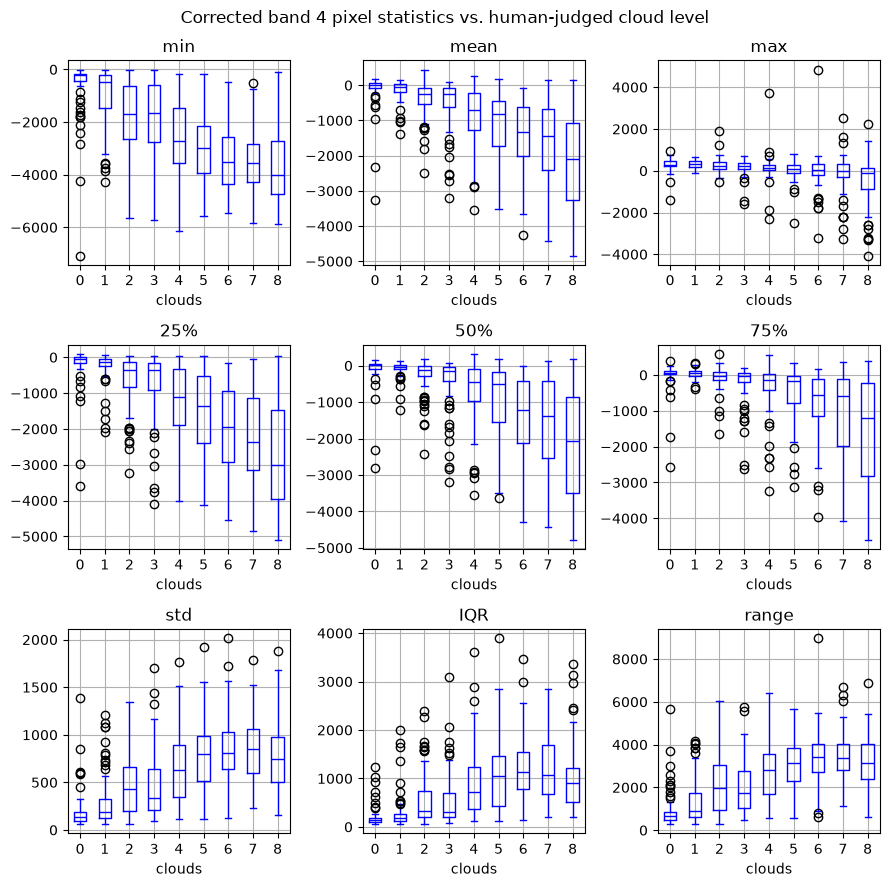

In [9]:
norm_samples = gc.as_value_frame(corrected, ('4corr', 'value'))
stats        = gc.compute_sample_stats(norm_samples, value_column='value')
_ = gc.plot_sample_stats(stats, title="Corrected band 4 pixel statistics vs. human-judged cloud level")

In [10]:
candidates = np.sort(norm_samples['value'].dropna().unique())
candidates = candidates[candidates < 0]
candidates = candidates[candidates > norm_samples.loc[norm_samples.clouds == 5, 'value'].median()]

In [11]:
%%time
#norm_samples  = gc.as_value_frame(corrected, ("4corr", "value"))
#norm_cloudcut = gc.reference_quantile(norm_samples, "value")
candidates = np.sort(norm_samples.value.dropna().astype(int).unique())
norm_cloudcut = gc.optimize_cloudcut_obs(norm_samples, "value", candidates=candidates)
norm_by_q     = gc.compute_by_quarter(norm_samples, "value", norm_cloudcut)

CPU times: user 2min 15s, sys: 14.1 ms, total: 2min 15s
Wall time: 2min 15s


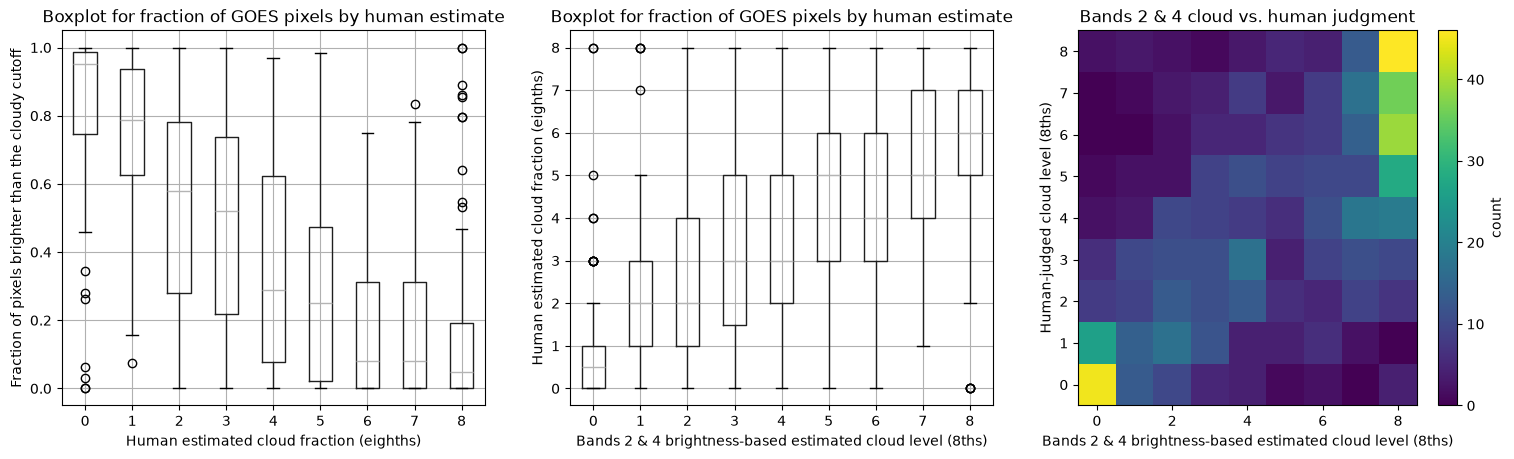

In [12]:
_ = gc.plot_norm_by_quarter(norm_by_q)

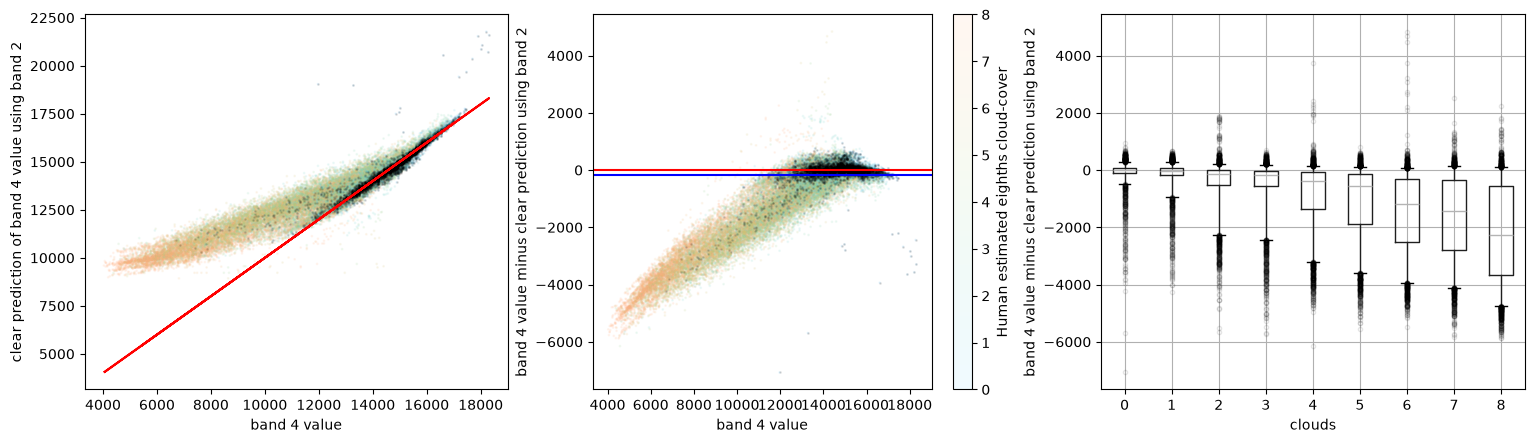

In [13]:
gc.plot_clear_sky_model(corrected, "value", x_band=2, y_band=4, cloudcut=norm_cloudcut)
None

## Comparing estimators

Per-band brightness cuts vs. the band-2-corrected cut, scored against
the human quarter reports.

In [14]:
by_quarter_per_band = {}
b_cloudcut = {}
for b in (2, 4, 6):
    b_samples = gc.as_value_frame(multiband, (b, "value"))
    b_cloudcut[b] = gc.optimize_cloudcut_obs(b_samples, "value")
    by_quarter_per_band[b] = gc.compute_by_quarter(b_samples, "value", b_cloudcut[b])

match_stats = gc.compare_estimates(multiband, {
    "cut on 2": by_quarter_per_band[2],
    "cut on 4": by_quarter_per_band[4],
    "cut on 6": by_quarter_per_band[6],
    "cut on 4 corrected by 2": norm_by_q,
})
for b in (2, 4, 6):
    match_stats.loc[f"cut on {b}", 'cloudcut'] = b_cloudcut[b]

match_stats.loc["cut on 4 corrected by 2", 'cloudcut'] = norm_cloudcut
match_stats

,n,n_exact,n_match_obs,human_mean_eighths,estimated_mean_eighths,frac_match_obs,cloudcut
cut on 2,746.0,154.0,567.0,3.941019,4.624665,0.760054,4992.0
cut on 4,768.0,168.0,594.0,3.955729,4.498698,0.773438,13664.0
cut on 6,768.0,163.0,605.0,3.955729,5.324219,0.787760,16128.0
cut on 4 corrected by 2,746.0,171.0,591.0,3.941019,4.639410,0.792225,-162.0


## Missing quarters, corrected

Apply the calibration-sample models and reference median to the 2015
quarters with a missing human report -- the models and `norm_cloudcut` come
from calibration; only the eighths come from the missing-quarter data
(this is the fix for `goesclouds.md` §4.8).

PosixPath('satellite_clouds_4corr2_2015.txt')

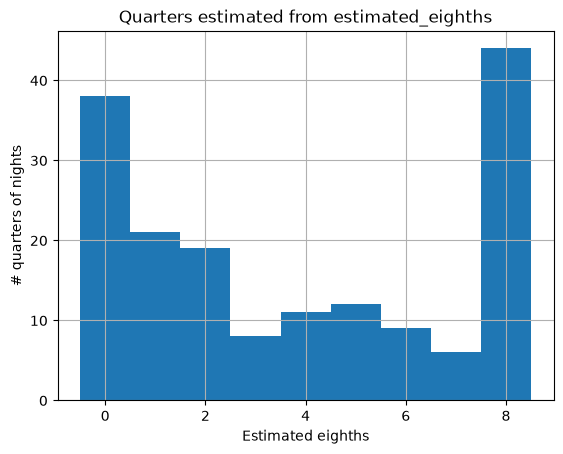

In [15]:
missing_multiband = gc.load_multiband_samples(missing_quarters, bands=(2, 4))
missing_corrected = gc.apply_clear_sky_correction(missing_multiband, models, x_band=2, y_band=4)
missing_norm      = gc.compute_by_quarter(
    gc.as_value_frame(missing_corrected, ("4corr", "value")), "value", norm_cloudcut,
)
gc.plot_estimate_histogram(missing_norm)
gc.write_band_estimates(missing_norm, "satellite_clouds_4corr2_2015.txt")